In [29]:
import neurokit2 as nk
import serial

## EOG

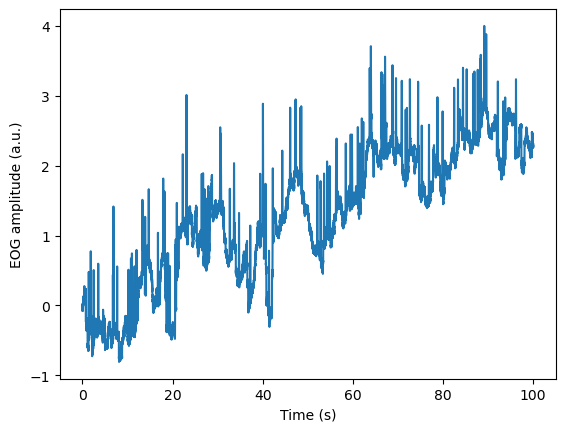

In [39]:
# Simulated EOG
# Created a custom implementation since neurokit2 doens't have eog_simulate
import numpy as np

def eog_simulate(duration=100, fs=500, blink_rate=1, saccade_rate=1.0):
    """
    Simulate a simple EOG signal.
    Args:
        duration (float): seconds
        fs (int): sampling frequency (Hz)
        blink_rate (float): average blinks per second
        saccade_rate (float): average saccades per second
    Returns:
        t (np.array): time vector
        eog (np.array): simulated EOG signal
    """
    t = np.arange(0, duration, 1/fs)
    eog = np.zeros_like(t)
    
    # Blinks: Gaussian-shaped pulses
    for _ in range(int(duration*blink_rate)):
        blink_time = np.random.uniform(0, duration)
        blink_idx = int(blink_time*fs)
        width = int(0.1*fs)  # 100 ms blink
        pulse = np.exp(-0.5*((np.arange(width)-width/2)/(0.02*fs))**2)
        end_idx = min(blink_idx+width, len(eog))
        eog[blink_idx:end_idx] += pulse[:end_idx-blink_idx]
    
    # Saccades: fast step-like changes
    for _ in range(int(duration*saccade_rate)):
        sacc_time = np.random.uniform(0, duration)
        sacc_idx = int(sacc_time*fs)
        step = np.random.uniform(-0.5,0.5)
        eog[sacc_idx:] += step
    
    # Add baseline drift & noise
    eog += 0.01*np.cumsum(np.random.randn(len(t)))  # slow drift
    eog += 0.01*np.random.randn(len(t))             # high-frequency noise
    
    return t, eog

import matplotlib.pyplot as plt
t, eog = eog_simulate()
plt.plot(t, eog)
plt.xlabel("Time (s)")
plt.ylabel("EOG amplitude (a.u.)")
plt.show()

In [34]:
# READ/WRITE SIGNAL BETWEEN PYTHON AND ARDUINO

In [31]:
# BLINK DETECTION


In [32]:
# SACCADE DETECTION


## EMG

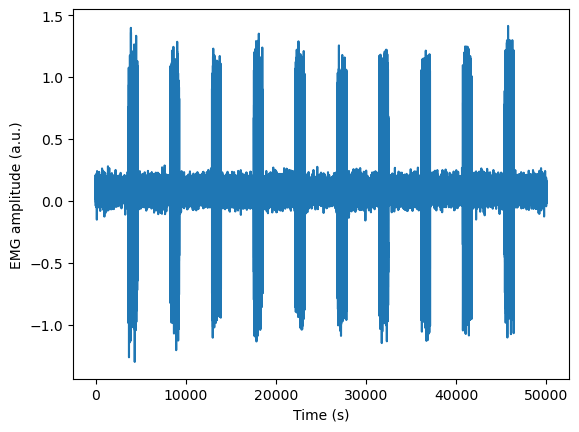

In [37]:
# Simulated EMG
import matplotlib.pyplot as plt
emg = nk.emg_simulate(duration=100,sampling_rate=500,burst_number=10,noise=0.05,burst_duration=2,)
plt.plot(emg)
plt.xlabel("Time (s)")
plt.ylabel("EMG amplitude (a.u.)")
plt.show()

In [36]:
# JAW CLENCH DETECTION